In [1]:
import sys, os
sys.path.append('/mnt/home/spandey/ceph/paste_godmax/GODMAX/src')
from godmax.base_class import get_vmapped_func
import jax.numpy as jnp
from jax import jit
from functools import partial
from mcfitjax.transforms import Hankel




In [17]:
import sys, os
# os.environ['PATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'+ os.environ['PATH']
# os.environ['PYTHONPATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.98'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')
import matplotlib
import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
import gc
# Palatino
# pl.rc('font', family='DejaVu Sans')
import ast
import yaml

# nside = int(ast.literal_eval(sys.argv[1]))
# print('nside: ', nside)
# jdevice = int(ast.literal_eval(sys.argv[2]))
# print('jdevice: ', jdevice)
# Ndevices = int(ast.literal_eval(sys.argv[3]))
# print('Ndevices: ', Ndevices)
nside = 2048
jdevice = 7
Ndevices = 8

def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

yaml_file_path = '/mnt/home/spandey/ceph/paste_godmax/GODMAX/param_files/params_default.yaml'
data = read_yaml(yaml_file_path)
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(data)

halo_params_dict['rmin'] = 0.0001
halo_params_dict['rmax'] = 10.0
halo_params_dict['nr'] = 126
halo_params_dict['zmin'] = 0.01
halo_params_dict['zmax'] = 4.1
halo_params_dict['nz'] = 127
halo_params_dict['lg10_Mmin'] = 12.0
halo_params_dict['lg10_Mmax'] = 16.0
halo_params_dict['nM'] = 128

from godmax.get_B12_profile import Battaglia_12_16
import helpers.constants as constants
# cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 69.0, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8':0.81 ,'ns': 0.965}
cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 67.74, 'Om0': 0.3089, 'Ob0': 0.0486, 'sigma8':0.8159 ,'ns': 0.9667}
# B12_test = Battaglia_12_16({'cosmo':cosmo_params_dict, 'init_power':False}, halo_params_dict)


B12_test = Battaglia_12_16(sim_params_dict={'cosmo':cosmo_params_dict, 'init_power':True}, halo_params_dict=halo_params_dict)







1 1


In [18]:
from astropy import constants as const
import astropy.units as u
import jax.scipy.integrate as jsi
sigmat = const.sigma_T
m_e = const.m_e
c = const.c
coeff = sigmat / (m_e * (c ** 2))
oneMpc = (((10 ** 6)) * (u.pc).to(u.m)) * (u.m)

const_coeff = (((coeff * oneMpc).to(((u.cm ** 3) / u.keV))).value)/(B12_test.cosmo_params['H0']/100.)
rp_array = B12_test.r_array[2:-2]
def get_y2D_phyical_proj(jrp, jz, jM, num_trapz_points=32):
    rp = rp_array[jrp]
    zval = B12_test.z_array[jz]
    r_array_here = jnp.exp(jnp.linspace(jnp.log(rp*1.01), jnp.log(jnp.max(B12_test.r_array)), num_trapz_points))
    Pe_rarray_here = jnp.exp(jnp.interp(jnp.log(r_array_here), jnp.log(B12_test.r_array/(1 + zval)), jnp.log(B12_test.Pe_mat_physical[:,jz, jM])))
    num = r_array_here * Pe_rarray_here
    denom = jnp.sqrt(r_array_here ** 2 - rp ** 2)
    toint = num / denom
    val = 2. * jsi.trapezoid(toint * r_array_here, jnp.log(r_array_here))
    # val = 2. * jsi.trapezoid(toint, (r_array_here))        
    return const_coeff * val





In [19]:
# get_y2D_phyical_proj(B12_test, 0, 0, 0)
from godmax.base_class import get_vmapped_func, get_vmapped_func_warg
y2D_mat_physical = get_vmapped_func(get_y2D_phyical_proj, 3)(jnp.arange(len(rp_array)), jnp.arange(len(B12_test.z_array)), jnp.arange(len(B12_test.M_array))).T



In [20]:
from mcfitjax.transforms import Hankel
def get_y2D_smoothed_prof(jz, jM):
    zval = B12_test.z_array[jz]
    DA_val = B12_test.DA_array[jz]
    theta_array = (rp_array / DA_val)  # in radians 
    ell_out, yell_out = (Hankel(theta_array, nu=0, q=1.0, nx=len(theta_array), lowring=True)(y2D_mat_physical[:,jz, jM], extrap=True))
    yell_out = jnp.array(yell_out * ((2 * jnp.pi)))   
    b_ell = jnp.exp(-0.5 * ell_out * (ell_out + 1.) * (sigma_val ** 2))

    theta_out, y_out_smooth = (Hankel(ell_out, nu=0, q=1.0, nx=len(ell_out), lowring=True)(jnp.clip(b_ell * yell_out, 1e-40, 1e10), extrap=True))
    y_out_smooth = jnp.array(y_out_smooth * (1./(2 * jnp.pi)))   
    y_out_smooth = jnp.clip(y_out_smooth, 1e-20, jnp.max(y2D_mat_physical[jz, jM]))

    return y_out_smooth





In [21]:
import healpy as hp
nside = 2048
theta_fwhm_arcmin = hp.nside2resol(nside, arcmin=True)
theta_fwhm_rad = (theta_fwhm_arcmin / 60.) * (jnp.pi / 180.)
sigma_val = theta_fwhm_rad / jnp.sqrt(8. * jnp.log(2.))


In [22]:
from godmax.base_class import get_vmapped_func, get_vmapped_func_warg
y2D_mat_smooth = get_vmapped_func(get_y2D_smoothed_prof, 2)(jnp.arange(len(B12_test.z_array)), jnp.arange(len(B12_test.M_array))).T




In [23]:
from mcfitjax.transforms import Hankel
def get_y2D_smoothed_prof(self, jz, jM):
    zval = self.z_array[jz]
    DA_val = self.DA_array[jz]
    theta_array = (self.rp_array / DA_val)  # in radians 
    ell_out, yell_out = (Hankel(theta_array, nu=0, q=1.0, nx=len(theta_array), lowring=True)(self.y2D_mat_physical[:,jz, jM], extrap=True))
    yell_out = jnp.array(yell_out * ((2 * jnp.pi)))   
    b_ell = jnp.exp(-0.5 * ell_out * (ell_out + 1.) * (self.sigma_val ** 2))

    theta_out, y_out_smooth = (Hankel(ell_out, nu=0, q=1.0, nx=len(ell_out), lowring=True)(jnp.clip(b_ell * yell_out, 1e-40, 1e10), extrap=True))
    y_out_smooth = jnp.array(y_out_smooth * (1./(2 * jnp.pi)))   
    y_out_smooth = jnp.clip(y_out_smooth, 1e-20, jnp.max(self.y2D_mat_physical[jz, jM]))

    return y_out_smooth





In [24]:
# B12_test.z_array[0]
# jnp.any(jnp.isnan(y2D_mat_smooth[:,1:,:]))
ind_nans = jnp.where(jnp.isnan(y2D_mat_smooth)== True)
y2D_mat_smooth = y2D_mat_smooth.at[ind_nans].set(y2D_mat_physical[ind_nans])


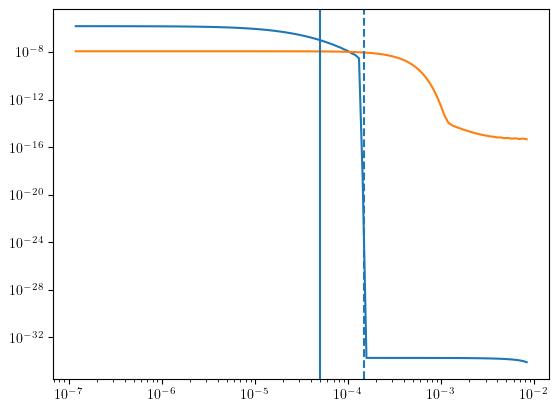

In [27]:
jz, jM = 120, 1
zval = B12_test.z_array[jz]
DA_val = B12_test.DA_array[jz]
theta_array = (rp_array / DA_val)  # in radians 
r200c_val = B12_test.r200c_mat[jM, jz]
theta_r200c = r200c_val/DA_val
theta_r200c, theta_r200c*60*180./jnp.pi

pl.figure()
pl.plot(theta_array, y2D_mat_physical[:,jz, jM])
pl.plot(theta_array, y2D_mat_smooth[:,jz, jM])
pl.axvline(theta_r200c)
pl.axvline(3*theta_r200c, ls='--')
# pl.ylim(1e-20, 2e-3)
pl.xscale('log')
pl.yscale('log')

